In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")

한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [2]:
# 문제 1: 배송사별 평균 배송 소요 시간(배송 시작~ 배송 완료)을 계산하고 비교하여 어느 배송사가 가장 빠른지 평가하세요.
# 시각화: 바 차트

# 비즈니스 목적: 물류 파트너(배송사)의 성과를 정량적으로 평가하여, 배송이 느린 업체를 교체하는 등의 의사결정에 활용합니다

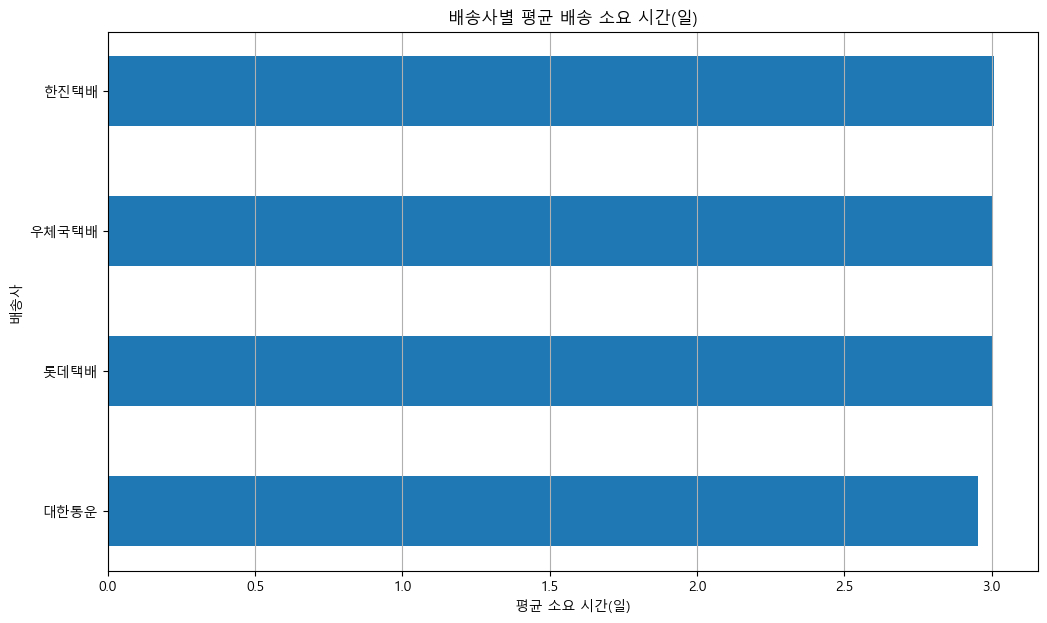

In [3]:
cols = ['shipping_company','shipping_start_date','shipping_end_date']

df_data1 = df[cols].copy()

df_data1['time_to_shipping'] = (df_data1['shipping_end_date'] - df_data1['shipping_start_date']).dt.days
shipping_duration = df_data1.groupby('shipping_company').mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(shipping_duration['shipping_company'], shipping_duration['time_to_shipping'],height=0.5)
ax.set_xlabel('평균 소요 시간(일)')
ax.set_ylabel('배송사')
ax.set_title('배송사별 평균 배송 소요 시간(일)')
ax.grid(axis='x')

plt.show()

In [4]:
# 문제 2: 고객의 거주 도시를 수도권/비수도권으로 나누고, 지역별 평균 배송 소요 시간에 차이가 있는지 분석하세요.
# 비즈니스 목적: 특정 지역에서 배송 지연이 발생하고 있는지 파악하고,
# 해당 지역의 물류 파트너를 변경하거나 추가적인 물류, 거점을 확보하는 등의 전략을 수립합니다.
# 수도권 서울/경기 비수도권

region
비수도권    2.996013
수도권     2.984239
Name: time_to_shipping, dtype: float64


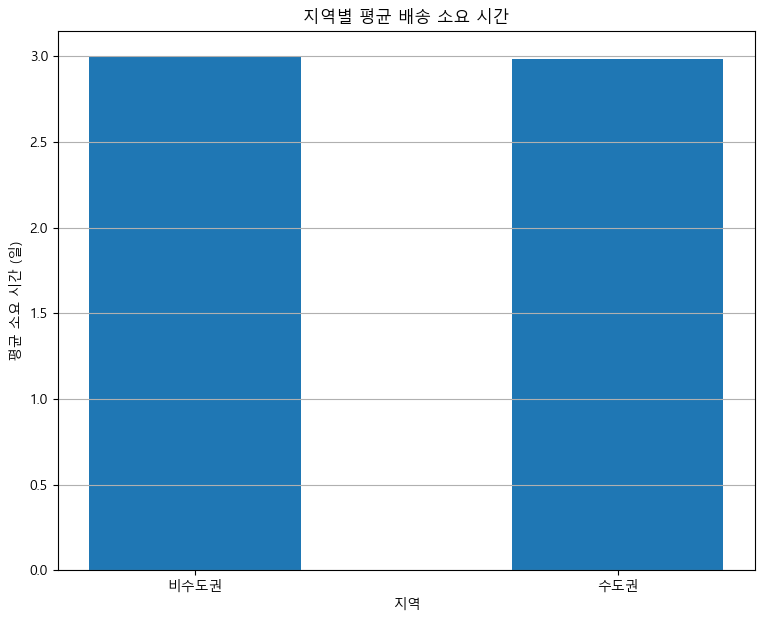

In [5]:
cols = ['city','shipping_start_date','shipping_end_date']

df_data2 = df[cols].copy()

df_data2['time_to_shipping'] = (df_data2['shipping_end_date'] - df_data2['shipping_start_date']).dt.days

metropolitan_keywords = ['서울', '경기', '인천']

def extract_province(city_name):
    # 시/군/구 이름에서 시도 추정
    if '서울' in city_name:
        return '서울'
    elif '인천' in city_name:
        return '인천'
    elif any(g in city_name for g in ['고양', '수원', '성남', '안양', '부천', '평택', '의정부', '광명', '하남', '이천', '용인', '남양주', '파주', '시흥', '군포', '의왕', '양주', '오산', '안성', '김포', '동두천', '과천', '연천', '가평', '양평']):
        return '경기'
    else:
        return '기타'

def classify_region(city_name):
    province = extract_province(city_name)
    return '수도권' if province in metropolitan_keywords else '비수도권'

df_data2['region'] = df_data2['city'].apply(classify_region)

region_stats = df_data2.groupby('region')['time_to_shipping'].mean()

print(region_stats)

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.bar(region_stats.index, region_stats.values, width=0.5)
ax.set_xlabel('지역')
ax.set_ylabel('평균 소요 시간 (일)')
ax.set_title('지역별 평균 배송 소요 시간')
ax.grid(True, axis='y')

In [6]:
# 문제 3: 배송 상태(shipping_status)별 주문 건수 분포를 확인하여 현재 물류 파이프라인의 병목 지점을 추정하세요
# 시각화: 바 차트
# 비즈니스 목적ㅣ 'Preparing'(준비중) 또는 'Shipped'(배송중) 단계에 주문이 과도하게 몰려있다면,
# 해당 단계(상품 준비, 출고 등)에 문제가 있을 수 있음을 파악하고 원인을 분석합니다.

                 count
shipping_status       
Delivered         5922
Shipped           1769
Preparing          895
Cancelled          457


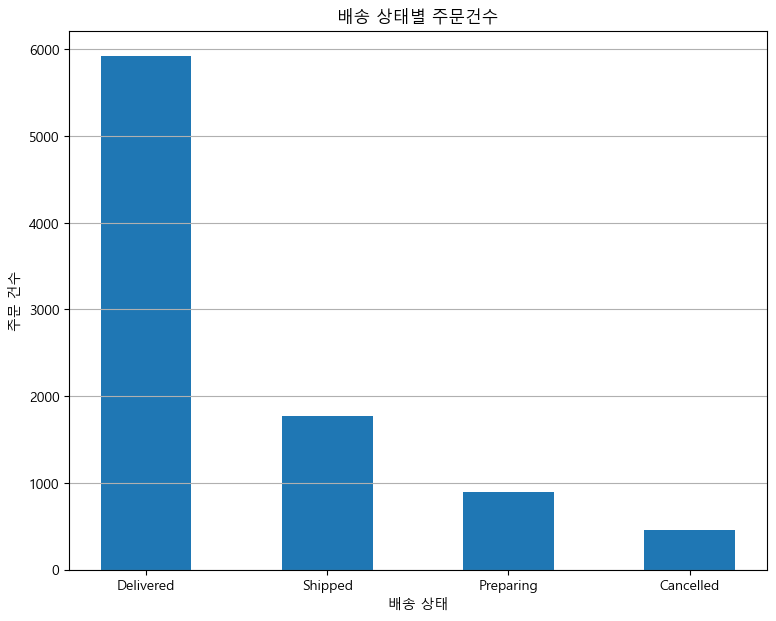

In [7]:
cols = ['shipping_status','order_id']

df_data3 = df[cols].copy()

group_shipping_status = df_data3.groupby('shipping_status').agg(
    count = ('order_id','count')
).sort_values('count',ascending=False)

print(group_shipping_status)

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.bar(group_shipping_status.index, group_shipping_status['count'], width=0.5)
ax.set_xlabel('배송 상태')
ax.set_ylabel('주문 건수')
ax.set_title('배송 상태별 주문건수')
ax.grid(True, axis='y')

In [8]:
# 문제 4: 주문 요일(주중/주말)에 따라 배송 시작까지 걸리는 시간(주문~배송 시작)에 차이가 있는지 분석하세요.
# 비즈니스 목적: 주말 주문 건이 물류센터 휴무등의 이유로 배송 시작이 지연되는지 확인하고,
# 인력 배치 조정이나 고객 안내 문구 변경 등의 조치를 취합니다

order_day_type
주말 주문    13.123632
주중 주문    12.905531
Name: start_to_shipping, dtype: float64


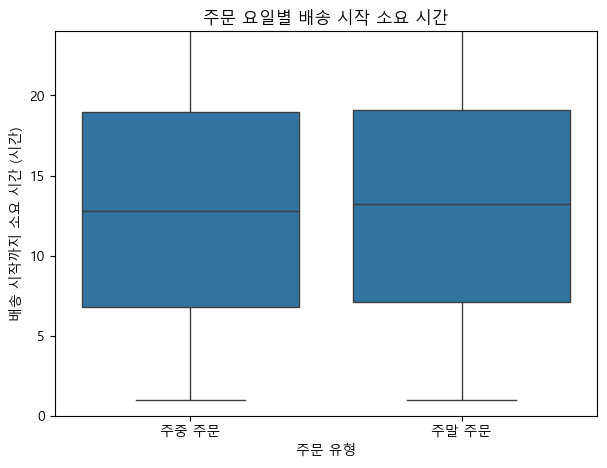

In [9]:
cols = ['order_date', 'shipping_start_date']

df_data4 = df[cols].copy()

df_data4['start_to_shipping'] = (df_data4['shipping_start_date'] - df_data4['order_date']).dt.total_seconds() / 3600

df_data4['start_to_order'] = df_data4['order_date'].dt.dayofweek

df_data4['is_weekend'] = df_data4['start_to_order'].apply(lambda x: 1 if x >= 5 else 0)

def classify_purchase_pattern(row):
    if row['is_weekend'] == 0:
        return '주중 주문'
    else:
        return '주말 주문'

# 패턴 분류 적용
df_data4['order_day_type'] = df_data4.apply(classify_purchase_pattern, axis=1)
time_to_ship = df_data4.groupby('order_day_type')['start_to_shipping'].mean()
print(time_to_ship)

fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(
    data=df_data4,
    x=df_data4['order_day_type'],
    y=df_data4['start_to_shipping'],
    ax=ax
)
ax.set_title('주문 요일별 배송 시작 소요 시간')
ax.set_xlabel('주문 유형')
ax.set_ylabel('배송 시작까지 소요 시간 (시간)')
ax.set_ylim(0,df_data4['start_to_shipping'].max()-1)

plt.show()

In [10]:
# 문제 5: 배송 완료까지 걸린 실제 시간과 주문 상품의 재고량 간의 관계를 분석하세요
# 비즈니스 목적: 재고가 부족한 상품의 배송이 더 오래 걸리는지(예: 다른 물류센터에서 가져오느라) 학인하고,
# 재고 관리 정책이 배송속도에 미치는 영향을 평가합니다.

  stock_bin  time_to_shipping
0     매우 적음          2.980815
1        적음          3.010265
2        보통          2.999156
3        많음          2.941638
4     매우 많음          3.023952


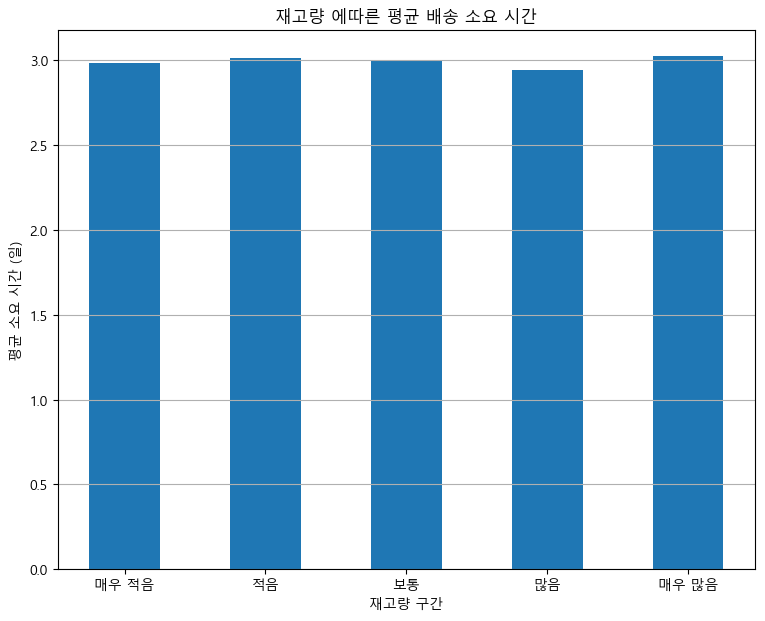

In [24]:
cols = ['stock', 'shipping_start_date','shipping_end_date']

df_data5 = df[cols].copy()

bins_quantile = [0,
                 df_data5['stock'].quantile(0.2),
                 df_data5['stock'].quantile(0.4),
                 df_data5['stock'].quantile(0.6),
                 df_data5['stock'].quantile(0.8),
                 df_data5['stock'].max() + 1]
labels_quantile = ['매우 적음', '적음', '보통', '많음', '매우 많음']

df_data5['stock_bin'] = pd.cut(df_data5['stock'], 
                                   bins=bins_quantile, 
                                   labels=labels_quantile, 
                                   include_lowest=True)

df_data5['time_to_shipping'] = (df_data5['shipping_end_date'] - df_data5['shipping_start_date']).dt.days

stock_per_shipping_date = df_data5.groupby('stock_bin', observed=False)['time_to_shipping'].mean().reset_index()

print(stock_per_shipping_date)

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.bar(stock_per_shipping_date['stock_bin'],stock_per_shipping_date['time_to_shipping'],width=0.5)
ax.set_xlabel('재고량 구간')
ax.set_ylabel('평균 소요 시간 (일)')
ax.set_title('재고량 에따른 평균 배송 소요 시간')
ax.grid(axis='y')
plt.show()